<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
《<a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a>》一书的补充代码，作者 <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码仓库：<a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第 4 章：从零实现用于生成文本的 GPT 模型

In [2]:
from importlib.metadata import version
# importlib.metadata 是 Python 3.8 及以上版本引入的模块，用于获取已安装包的版本信息。

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.11.0
torch version: 2.7.1+cu118
tiktoken version: 0.13.0


- 在本章中，我们实现一个类似 GPT 的 LLM 架构；下一章将重点训练这个 LLM

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/01.webp" width="1000px">

&nbsp;
## 4.1 编写 LLM 架构

- 第 1 章讨论过 GPT 和 Llama 这类模型：它们按顺序生成词，并基于原始 transformer 架构中的 decoder 部分
- 因此，这类 LLM 通常也被称为“类 decoder”LLM
- 与传统深度学习模型相比，LLM 更大，主要原因是参数数量巨大，而不是代码量巨大
- 我们会看到，LLM 架构中有很多元素是重复堆叠的

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="1000px">

- 在前几章中，为了便于说明并让内容适合放在单页图中，我们使用了较小的 token 输入和输出嵌入维度
- 在本章中，我们会考虑接近小型 GPT-2 模型的嵌入维度和模型大小
- 我们将专门编写最小 GPT-2 模型（1.24 亿参数）的架构，参考 Radford 等人的 [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)（注意，最初报告中写的是 117M 参数，但后来在模型权重仓库中更正了）
- 第 6 章会展示如何把预训练权重加载到我们的实现中，并兼容 345M、762M 和 1542M 参数规模的模型

- 1.24 亿参数 GPT-2 模型的配置细节包括：

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 词表大小
    "context_length": 1024, # 上下文长度
    "emb_dim": 768,         # 嵌入维度
    "n_heads": 12,          # 注意力 head 数量
    "n_layers": 12,         # 层数
    "drop_rate": 0.1,       # Dropout 比率
    "qkv_bias": False       # Query-Key-Value 偏置
}

- 我们使用较短的变量名，以避免后面的代码行过长
- `"vocab_size"` 表示词表大小为 50,257，对应第 2 章讨论过的 BPE tokenizer
- `"context_length"` 表示模型最多可接收的输入 token 数，这由第 2 章介绍的位置嵌入支持
- `"emb_dim"` 是 token 输入的嵌入大小，会把每个输入 token 转换为 768 维向量
- `"n_heads"` 是第 3 章实现的多头注意力机制中的注意力头数量
- `"n_layers"` 是模型中的 transformer block 数量，我们会在接下来的小节中实现
- `"drop_rate"` 是第 3 章讨论过的 dropout 强度；0.1 表示训练时丢弃 10% 的隐藏单元，用于缓解过拟合
- `"qkv_bias"` 决定第 3 章多头注意力机制中的 `Linear` 层，在计算 query（Q）、key（K）和 value（V）张量时是否包含偏置向量；这里我们关闭该选项，这是现代 LLM 的常见做法；不过在第 5 章把 OpenAI 预训练 GPT-2 权重加载到我们的重实现中时，我们会再次讨论它

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

In [4]:
import torch
import torch.nn as nn
#torch.nn 是 PyTorch 中用于构建神经网络的模块，包含了各种层、损失函数等工具。

#Dummy 是一个占位符，表示这个类只是为了演示结构而存在，并没有实际的功能实现。
class DummyGPTModel(nn.Module):
#cfg 是一个配置字典，包含了模型的各种超参数和设置。
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        # Sequential 是 PyTorch 中的一个容器模块，可以将多个层组合成一个新的模块。
        # 这里我们用它来组合多个 DummyTransformerBlock。
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        #把 12 个 TransformerBlock 串起来，输入依次通过这 12 层。

        # Use a placeholder for LayerNorm
        # LayerNorm 是一种归一化方法，通常用于 Transformer 模型中。
        # 这里我们用 DummyLayerNorm 来占位。
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        #Liner 是 PyTorch 中的全连接层，这里我们用它来将嵌入维度映射到词表大小，
        # 以输出每个位置的词概率分布。
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    # 前向传播函数，定义了模型在接收输入时的计算流程。
    # in_idx 是输入的索引张量，形状为 (batch_size, seq_len)，表示每个位置的词索引。
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        #self.trf_blocks = nn.Sequential(
        #    *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        x = self.final_norm(x)
        #[2, 4, 768] → [2, 4, 50257]
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        #super().__init__()，这一句是调用父类的初始化函数。
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

forward()举例理解：

比如：

tensor([
    [6109, 3626, 6100, 345],
    [6109, 1110, 6622, 257]
])

这里每个数字都是 tokenizer 编出来的 token id。

tok_embeds = self.tok_emb(in_idx)

作用：

token id → token vector

形状变化：

[2, 4] → [2, 4, 768]

LayerNorm 是 层归一化，作用是把每个 token 的特征向量变得更稳定。

比如一个 token 的向量是 768 维，LayerNorm 会对这 768 个数算均值和方差，然后做：

x = (x - mean) / sqrt(var + eps)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="1000px">

In [5]:
# tiktoken 是 OpenAI 开发的一个用于文本编码的库，支持多种编码方式，
# 包括 GPT-2 的 BPE 编码。
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

#batch用于存储多个输入文本的编码结果。
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


---

**注意**

- 如果你在 Windows 或 Linux 上运行这段代码，上面的结果可能类似如下：
    
```
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
```

- 由于这些只是随机数，所以不用担心，可以继续学习本章剩余内容
- 这种差异的一个可能原因是，不同操作系统上的 `nn.Dropout` 行为会有所不同，具体取决于 PyTorch 的编译方式；相关讨论见 [PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

---

&nbsp;
## 4.2 使用层归一化规范化激活值

- 层归一化，也称为 LayerNorm（[Ba et al. 2016](https://arxiv.org/abs/1607.06450)），会把神经网络层的激活值围绕均值 0 居中，并把方差归一化为 1
- 这会稳定训练过程，并帮助模型更快收敛到有效权重
- 在后面要实现的 transformer block 中，层归一化会应用在多头注意力模块的前后；它也会应用在最终输出层之前

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

- 先通过一个简单神经网络层传入小型输入样本，看看层归一化是如何工作的：

In [7]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- 下面计算上面 2 个输入各自的均值和方差：

In [8]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


- 归一化会分别应用到两个输入（两行）上；使用 `dim=-1` 表示沿最后一个维度（这里是特征维度）计算，而不是沿行维度计算

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/06.webp" width="1000px">

- 减去均值并除以方差的平方根（标准差），会让输入在列（特征）维度上中心化为均值 0、方差 1：

In [9]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)
#keepdim=True 参数保持维度不变，使得 mean 和 var 的形状与 out 相同，方便后续的广播操作。
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 每个输入都以 0 为中心，并具有单位方差 1；为了提升可读性，我们可以关闭 PyTorch 的科学计数法：

In [10]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- 上面我们对每个输入的特征做了归一化
- 现在，使用同样的思想，可以实现一个 `LayerNorm` 类：

In [11]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5#eps防止除0
        #Parameter可训练参数
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**缩放和平移**

- 注意，除了通过减均值、除以方差来执行归一化之外，我们还添加了两个可训练参数：`scale` 和 `shift`
- 初始 `scale`（乘以 1）和 `shift`（加 0）不会产生影响；不过 `scale` 和 `shift` 是可训练参数，如果训练过程中模型判断这样能提升任务表现，LLM 会自动调整它们
- 这使模型可以学习最适合当前数据的缩放和平移
- 注意，我们在计算方差平方根之前还加了一个很小的值（`eps`）；这是为了在方差为 0 时避免除零错误

**有偏方差**
- 在上面的方差计算中，设置 `unbiased=False` 表示使用公式 $\frac{\sum_i (x_i - \bar{x})^2}{n}$ 计算方差，其中 n 是样本大小（这里是特征数或列数）；这个公式不包含贝塞尔校正（后者会在分母中使用 `n-1`），因此给出的是有偏方差估计
- 对 LLM 来说，嵌入维度 `n` 通常很大，有偏估计和无偏估计的差异可以忽略；GPT-2 等实现也使用这种有偏方差形式

为什么要这样？

因为有时候完全强行变成均值 0、方差 1 不一定最优。scale 和 shift 给模型一个自由度，让它在训练中自己决定：

这个特征应该放大一点？
这个特征应该整体偏移一点？

In [12]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [13]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


- 方差并不精确等于 1，因为我们使用了 `eps`

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/07.webp" width="1000px">

&nbsp;
## 4.3 使用 GELU 激活实现前馈网络

- 本节中，我们实现一个小型神经网络子模块，它会作为 LLM 中 transformer block 的一部分
- 我们从激活函数开始
- 在深度学习中，ReLU（Rectified Linear Unit）激活函数因简单且在多种神经网络架构中有效而被广泛使用
- 在 LLM 中，除了传统 ReLU 之外，还会使用多种其他激活函数；两个典型例子是 GELU（Gaussian Error Linear Unit）和 SwiGLU（Swish-Gated Linear Unit）
- GELU 和 SwiGLU 是更复杂、平滑的激活函数，分别引入高斯和 sigmoid 门控线性单元；与 ReLU 这种更简单的分段线性函数相比，它们通常能为深度学习模型带来更好表现

- GELU（[Hendrycks and Gimpel 2016](https://arxiv.org/abs/1606.08415)）可以用多种方式实现；精确版本定义为 GELU(x)=x⋅Φ(x)，其中 Φ(x) 是标准高斯分布的累积分布函数。
- 实践中，常用一个计算成本更低的近似式：$\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$（原始 GPT-2 模型也是使用这个近似式训练的）

In [14]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

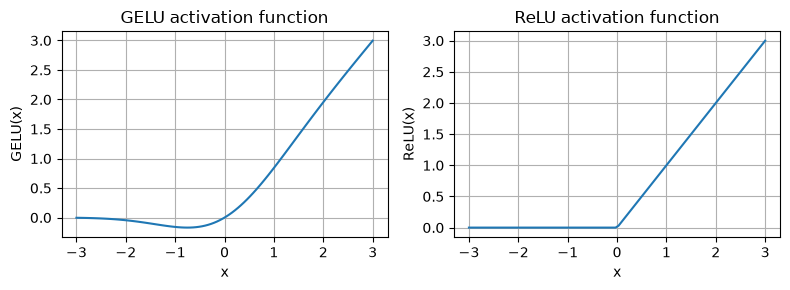

In [15]:
#pyplot 是 Matplotlib 库中的一个模块，用于创建各种类型的图表和可视化。
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
#linspace 是 PyTorch 中的一个函数，用于生成指定范围内的等间隔数值序列。
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- 可以看到，ReLU 是分段线性函数：如果输入为正，就直接输出输入；否则输出 0
- GELU 是平滑的非线性函数，它近似 ReLU，但对负值仍有非零梯度（约 -0.75 附近除外）

- 接下来，实现稍后会在 LLM transformer block 中使用的小型神经网络模块 `FeedForward`：
- 这是 TransformerBlock 里的 FFN，也叫 MLP 子层

In [16]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [17]:
print(GPT_CONFIG_124M["emb_dim"])

768


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="1000px">

In [18]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/10.webp" width="1000px">

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/11.webp" width="1000px">

&nbsp;
## 4.4 添加快捷连接

- 接下来讨论 shortcut connection，也叫 skip connection 或 residual connection
- shortcut connection 最初是在计算机视觉的深层网络（残差网络）中提出的，用于缓解梯度消失问题
- shortcut connection 会为梯度在网络中流动创建一条更短的替代路径
- 实现方式通常是把某一层的输出加到后面某一层的输出上，中间跳过一层或多层
- 下面用一个小型示例网络说明这个思想：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123" width="1000px">

- 在代码中，它看起来像这样：

In [19]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # ModuleList 是 PyTorch 中的一个容器模块，用于存储一系列子模块。
        # 与 Sequential 不同，ModuleList 不会自动将子模块串联起来，
        # 而是允许我们在 forward 方法中灵活地使用这些子模块。
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


#gradients 是神经网络训练过程中计算的导数，用于更新模型参数以最小化损失函数。
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    #[0.]表示一个元素 0.0，作为目标值。
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    # MSELoss 是 PyTorch 中的一个损失函数，用于计算均方误差（Mean Squared Error），
    # 适用于回归问题。它计算输出和目标之间的平均平方差
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    # backward() 是 PyTorch 中用于计算梯度的函数，
    # 它会根据当前的计算图自动计算所有需要更新的参数的梯度。
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

- 先打印**不使用** shortcut connection 时的梯度值：

In [20]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


- 接着打印**使用** shortcut connection 时的梯度值：

In [21]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


- 从上面的输出可以看到，shortcut connection 可以防止早期层（靠近 `layer.0`）中的梯度消失
- 接下来实现 transformer block 时，我们会使用这个 shortcut connection 概念

&nbsp;
## 4.5 在 transformer block 中连接注意力层和线性层

- 本节中，我们把前面几个概念组合成所谓的 transformer block
- transformer block 会把上一章的 causal multi-head attention 模块与线性层、以及前面实现的 feed forward 神经网络组合起来
- 此外，transformer block 还会使用 dropout 和 shortcut connection

In [22]:
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch03 import MultiHeadAttention

from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # attention block 的快捷连接
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # 形状 [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # 把原始输入加回来

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # 把原始输入加回来

        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="1000px">

- 假设有 2 个输入样本，每个样本包含 4 个 token，每个 token 是一个 768 维嵌入向量；那么这个 transformer block 会先应用 self-attention，再应用线性层，产生大小相似的输出
- 你可以把这个输出理解为上一章讨论过的 context vector 的增强版本

In [23]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/14.webp?1" width="1000px">

&nbsp;
## 4.6 编写 GPT 模型

- 我们快完成了：现在把 transformer block 接入本章开头编写的架构中，从而得到一个可用的 GPT 架构
- 注意，transformer block 会重复多次；以最小的 124M GPT-2 模型为例，会重复 12 次：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="1000px">

- 对应的代码实现如下，其中 `cfg["n_layers"] = 12`：

In [24]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # 形状 [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- 使用 124M 参数模型的配置，现在可以像下面这样用随机初始权重实例化这个 GPT 模型：

In [25]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


- 下一章会训练这个模型
- 不过，先简单说明一下它的大小：前面我们称它为 124M 参数模型；可以像下面这样再次核对这个数字：

In [ ]:
#numel() 是 PyTorch 中的一个方法，用于返回张量中元素的总数。
total_params = sum(p.numel() for p in model.parameters())
print(list(model.parameters()))
print(f"Total number of parameters: {total_params:,}")

[Parameter containing:
tensor([[     0.3374,     -0.1778,     -0.3035,  ...,     -0.3181,
             -1.3936,      0.5226],
        [     0.2579,      0.3420,     -0.8168,  ...,     -0.4098,
              0.4978,     -0.3721],
        [     0.7957,      0.5350,      0.9427,  ...,     -1.0749,
              0.0955,     -1.4138],
        ...,
        [    -0.7128,     -0.5019,      1.4119,  ...,     -0.1498,
             -0.4898,     -1.0620],
        [     2.0646,      1.1190,      0.3849,  ...,     -0.7202,
             -0.5570,      0.9864],
        [     0.0011,     -0.7532,     -0.1792,  ...,     -0.3244,
              0.2606,      0.5889]], requires_grad=True), Parameter containing:
tensor([[ 0.8769,  0.2550,  0.8441,  ..., -1.0354,  1.3085,  1.7957],
        [-1.0029,  0.0995,  1.2459,  ...,  1.5453, -0.1126, -1.5197],
        [ 1.3317,  0.7561,  0.9077,  ...,  0.0830,  1.8336, -2.2225],
        ...,
        [-0.1055, -1.1941, -1.1472,  ..., -1.4544,  0.2918, -0.5483],
        [

AttributeError: 'list' object has no attribute 'shape'

- 如上所示，这个模型有 163M 参数，而不是 124M；为什么？
- 在原始 GPT-2 论文中，研究者使用了权重绑定，也就是复用 token embedding 层（`tok_emb`）作为输出层，这意味着设置 `self.out_head.weight = self.tok_emb.weight`
- token embedding 层把 50,257 维 one-hot 编码输入 token 投影为 768 维嵌入表示
- 输出层把 768 维嵌入投影回 50,257 维表示，以便把它们转换回词（下一节会进一步说明）
- 因此，从权重矩阵形状可以看出，embedding 层和输出层拥有相同数量的权重参数
- 不过，先简单说明一下它的大小：前面我们称它为 124M 参数模型；可以像下面这样再次核对这个数字：

In [29]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


- 在原始 GPT-2 论文中，研究者复用了 token embedding 矩阵作为输出矩阵
- 因此，如果从总参数中减去输出层参数数量，就会得到 124M 参数模型：

In [31]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- 实践中，我发现不使用权重绑定训练模型更容易，因此这里没有实现它
- 不过，在第 5 章加载预训练权重时，我们会重新讨论并应用这个权重绑定思想
- 最后，可以像下面这样计算模型的内存需求，这可以作为一个有用的参考点：

In [32]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


- 练习：你也可以尝试下面这些其他配置，它们同样来自 [GPT-2 论文](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C)。

    - **GPT2-small**（我们已经实现的 124M 配置）：
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium：**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large：**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL：**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

&nbsp;
## 4.7 生成文本

- 像上面实现的 GPT 模型这样的 LLM，会一次生成一个词

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="1000px">

- 下面的 `generate_text_simple` 函数实现了 greedy decoding（贪心解码），这是一种简单快速的文本生成方法
- 在 greedy decoding 中，每一步模型都会选择概率最高的词（或 token）作为下一个输出（最高 logit 对应最高概率，因此严格来说甚至不需要显式计算 softmax）
- 下一章会实现更高级的 `generate_text` 函数
- 下图展示了 GPT 模型在给定输入上下文时如何生成下一个词 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="1000px">

In [33]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context --- IGNORE ---
    #max_new_tokens 是我们希望生成的新 token 的数量，context_size 是模型支持的最大上下文长度。
    for _ in range(max_new_tokens):
        
        # 如果当前上下文超过支持的上下文大小，则进行裁剪
        # 例如，如果 LLM 只支持 5 个 token，而上下文大小是 10
        # 那么只会使用最后 5 个 token 作为上下文
        idx_cond = idx[:, -context_size:]
        
        # 获取预测结果
        # no_grad() 是 PyTorch 中的一个上下文管理器，用于在其作用范围内禁用梯度计算。
        with torch.no_grad():
            logits = model(idx_cond)
        
        # 只关注最后一个时间步
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        # 从 probas 中获取每个样本的最高概率值对应的索引
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 将采样得到的索引追加到当前序列
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

- 上面的 `generate_text_simple` 实现了一个迭代过程，每次创建一个 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/18.webp" width="1000px">

- 准备一个输入示例：

In [34]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [35]:
#eval() 是 PyTorch 中的一个方法，用于将模型设置为评估模式。
# 在评估模式下，某些层（如 dropout 和 batch normalization）会表现出不同的行为。
model.eval() # 禁用 dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


- 移除 batch 维度，并转换回文本：

In [37]:
#squeeze(0) 是 PyTorch 中的一个方法，用于去除指定维度（这里是第 0 维）的大小为 1 的维度。
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


- 注意，该模型还没有训练，因此上面的输出文本是随机的
- 下一章会训练这个模型

&nbsp;
## 总结和要点

- 参见 [./gpt.py](./gpt.py) 脚本，它是一个自包含脚本，包含我们在这个 Jupyter notebook 中实现的 GPT 模型
- 练习答案可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到